## Impact of Handwashing on Maternal Mortality Analysis
##### Part 1: Yearly Analysis


##### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

##### Load Yearly Dataset

In [2]:
yearly = pd.read_csv("yearly_deaths_by_clinic.csv")

##### Dataset Exploration

In [3]:
yearly.head()

,year,births,deaths,clinic
0,1841,3036,237,clinic 1
1,1842,3287,518,clinic 1
2,1843,3060,274,clinic 1
3,1844,3157,260,clinic 1
4,1845,3492,241,clinic 1


In [4]:
yearly.tail()

,year,births,deaths,clinic
7,1842,2659,202,clinic 2
8,1843,2739,164,clinic 2
9,1844,2956,68,clinic 2
10,1845,3241,66,clinic 2
11,1846,3754,105,clinic 2


In [5]:
yearly.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   year    12 non-null     int64 
 1   births  12 non-null     int64 
 2   deaths  12 non-null     int64 
 3   clinic  12 non-null     object
dtypes: int64(3), object(1)
memory usage: 516.0+ bytes


In [6]:
yearly.shape

(12, 4)

In [7]:
yearly.describe()

,year,births,deaths
count,12.000000,12.000000,12.000000
mean,1843.500000,3152.750000,223.333333
std,1.783765,449.078476,145.383089
min,1841.000000,2442.000000,66.000000
25%,1842.000000,2901.750000,100.250000
50%,1843.500000,3108.500000,219.500000
75%,1845.000000,3338.250000,263.500000
max,1846.000000,4010.000000,518.000000


In [8]:
yearly.columns

Index(['year', 'births', 'deaths', 'clinic'], dtype='object')

In [9]:
yearly.isnull().sum()

year      0
births    0
deaths    0
clinic    0
dtype: int64

In [10]:
yearly.nunique()

year       6
births    12
deaths    12
clinic     2
dtype: int64

##### Understanding the Data

In [11]:
yearly['clinic'].unique()

array(['clinic 1', 'clinic 2'], dtype=object)

In [12]:
yearly['clinic'].value_counts()

clinic
clinic 1    6
clinic 2    6
Name: count, dtype: int64

##### Calculate Death Proportion

In [13]:
yearly['proportion_deaths'] = (
    yearly['deaths'] /
    yearly['births']
)

In [14]:
yearly.head()

,year,births,deaths,clinic,proportion_deaths
0,1841,3036,237,clinic 1,0.078063
1,1842,3287,518,clinic 1,0.157591
2,1843,3060,274,clinic 1,0.089542
3,1844,3157,260,clinic 1,0.082357
4,1845,3492,241,clinic 1,0.069015


##### Separate Clinics

In [15]:
clinic_1 = yearly[
    yearly['clinic'] == 'clinic 1'
]

clinic_2 = yearly[
    yearly['clinic'] == 'clinic 2'
]

In [16]:
clinic_1.head()

,year,births,deaths,clinic,proportion_deaths
0,1841,3036,237,clinic 1,0.078063
1,1842,3287,518,clinic 1,0.157591
2,1843,3060,274,clinic 1,0.089542
3,1844,3157,260,clinic 1,0.082357
4,1845,3492,241,clinic 1,0.069015


In [17]:
clinic_2.head()

,year,births,deaths,clinic,proportion_deaths
6,1841,2442,86,clinic 2,0.035217
7,1842,2659,202,clinic 2,0.075968
8,1843,2739,164,clinic 2,0.059876
9,1844,2956,68,clinic 2,0.023004
10,1845,3241,66,clinic 2,0.020364


In [18]:
yearly.shape

(12, 5)

In [19]:
yearly['clinic'].value_counts()

clinic
clinic 1    6
clinic 2    6
Name: count, dtype: int64

#### Compare Births by Clinic

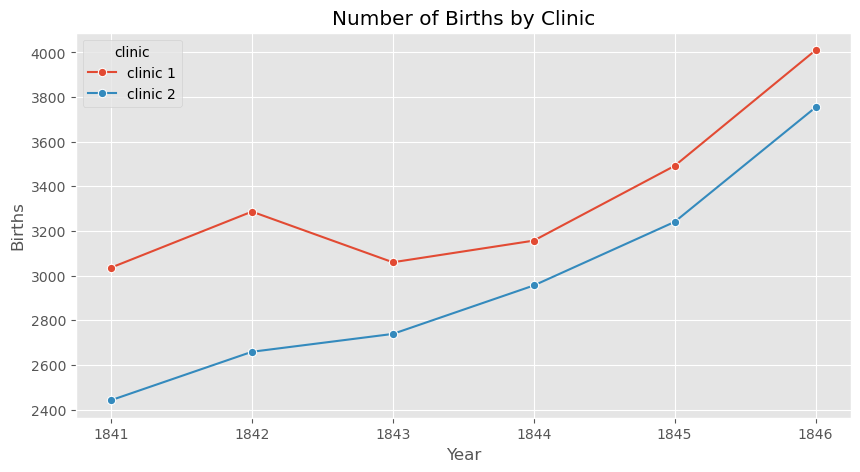

In [20]:
plt.figure(figsize=(10,5))

sns.lineplot(
    data=yearly,
    x='year',
    y='births',
    hue='clinic',
    marker='o'
)

plt.title('Number of Births by Clinic')
plt.xlabel('Year')
plt.ylabel('Births')
plt.show()

###### Compare how many births occurred in each clinic every year.

#### Compare Deaths by Clinic

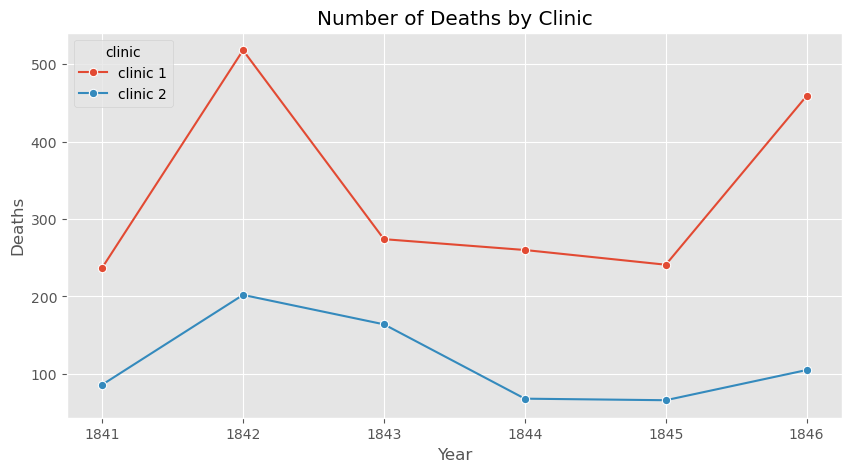

In [21]:
plt.figure(figsize=(10,5))

sns.lineplot(
    data=yearly,
    x='year',
    y='deaths',
    hue='clinic',
    marker='o'
)

plt.title('Number of Deaths by Clinic')
plt.xlabel('Year')
plt.ylabel('Deaths')
plt.show()

###### Shows which clinic had more maternal deaths.

#### Proportion of Deaths Trend

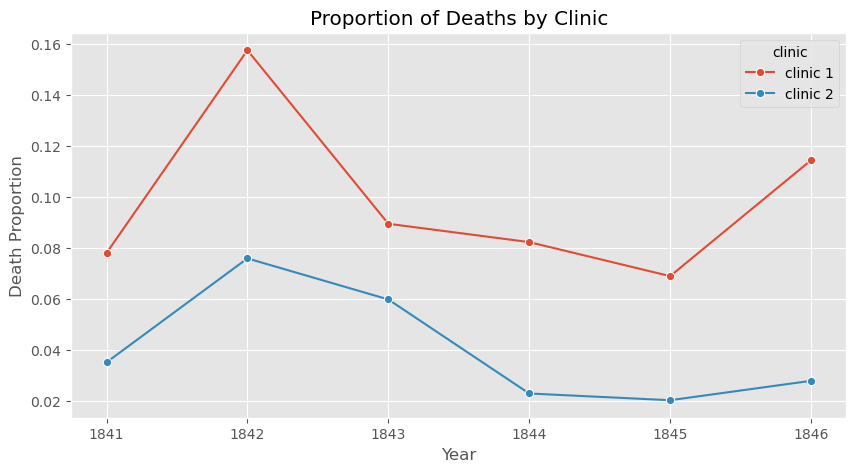

In [22]:
plt.figure(figsize=(10,5))

sns.lineplot(
    data=yearly,
    x='year',
    y='proportion_deaths',
    hue='clinic',
    marker='o'
)

plt.title('Proportion of Deaths by Clinic')
plt.xlabel('Year')
plt.ylabel('Death Proportion')
plt.show()

###### It shows mortality rate instead of raw deaths.

##### Average Mortality by Clinic

In [23]:
yearly.groupby('clinic')['proportion_deaths'].mean()

clinic
clinic 1    0.098505
clinic 2    0.040400
Name: proportion_deaths, dtype: float64

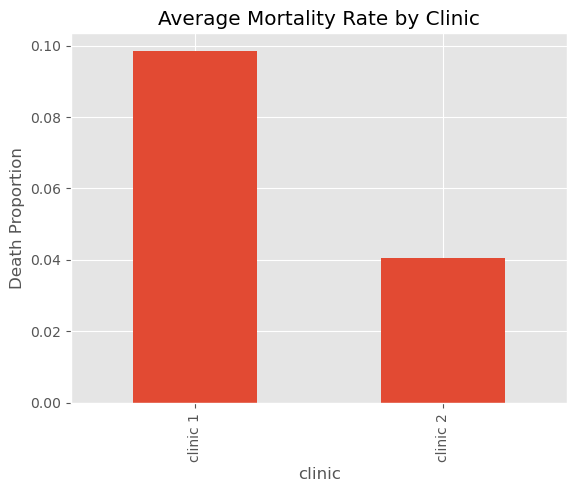

In [24]:
yearly.groupby('clinic')['proportion_deaths'].mean().plot(
    kind='bar'
)

plt.title('Average Mortality Rate by Clinic')
plt.ylabel('Death Proportion')
plt.show()

###### Which clinic had the highest average mortality rate?

#### Identify Worst Year

In [26]:
yearly.loc[
    yearly['proportion_deaths'].idxmax()
]

year                     1842
births                   3287
deaths                    518
clinic               clinic 1
proportion_deaths    0.157591
Name: 1, dtype: object

###### Find the year with the highest mortality rate.

#### Identify Best Year

In [27]:
yearly.loc[
    yearly['proportion_deaths'].idxmin()
]

year                     1845
births                   3241
deaths                     66
clinic               clinic 2
proportion_deaths    0.020364
Name: 10, dtype: object

###### Find the year with the lowest mortality rate.

#### Summary Statistics

In [28]:
yearly.groupby('clinic')[
    'proportion_deaths'
].agg(
    ['mean','min','max']
)

,mean,min,max
clinic,,,
clinic 1,0.098505,0.069015,0.157591
clinic 2,0.040400,0.020364,0.075968


### Part 2: Monthly Analysis (Did Handwashing Work?)

#### Load Monthly Dataset

In [30]:
monthly = pd.read_csv("monthly_deaths.csv")

#### Explore Dataset

In [31]:
monthly.head()

,date,births,deaths
0,1841-01-01,254,37
1,1841-02-01,239,18
2,1841-03-01,277,12
3,1841-04-01,255,4
4,1841-05-01,255,2


In [32]:
monthly.tail()

,date,births,deaths
93,1848-11-01,310,9
94,1848-12-01,373,5
95,1849-01-01,403,9
96,1849-02-01,389,12
97,1849-03-01,406,20


In [33]:
monthly.shape

(98, 3)

In [34]:
monthly.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98 entries, 0 to 97
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   date    98 non-null     object
 1   births  98 non-null     int64 
 2   deaths  98 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 2.4+ KB


In [35]:
monthly.describe()

,births,deaths
count,98.000000,98.000000
mean,267.000000,22.469388
std,41.769372,18.141031
min,190.000000,0.000000
25%,242.500000,8.000000
50%,264.000000,16.500000
75%,292.750000,36.750000
max,406.000000,75.000000


In [36]:
monthly.columns

Index(['date', 'births', 'deaths'], dtype='object')

In [37]:
monthly.isnull().sum()

date      0
births    0
deaths    0
dtype: int64

#### Convert Date Column 

In [39]:
monthly['date'] = pd.to_datetime(
    monthly['date']
)

In [40]:
monthly.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98 entries, 0 to 97
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    98 non-null     datetime64[ns]
 1   births  98 non-null     int64         
 2   deaths  98 non-null     int64         
dtypes: datetime64[ns](1), int64(2)
memory usage: 2.4 KB


#### Calculate Death Proportion

In [41]:
monthly['proportion_deaths'] = (
    monthly['deaths'] /
    monthly['births']
)

In [42]:
monthly.head()

,date,births,deaths,proportion_deaths
0,1841-01-01,254,37,0.145669
1,1841-02-01,239,18,0.075314
2,1841-03-01,277,12,0.043321
3,1841-04-01,255,4,0.015686
4,1841-05-01,255,2,0.007843


#### Define Handwashing Start Date

###### Dr. Semmelweis introduced handwashing in June 1847.

In [44]:
handwashing_start = pd.to_datetime(
    '1847-06-01'
)

#### Split Dataset

###### Before Handwashing

In [45]:
before_washing = monthly[
    monthly['date'] < handwashing_start
]

###### After Handwashing

In [46]:
after_washing = monthly[
    monthly['date'] >= handwashing_start
]

In [47]:
before_washing.shape

(76, 4)

In [48]:
after_washing.shape

(22, 4)

#### Visualize Before vs After

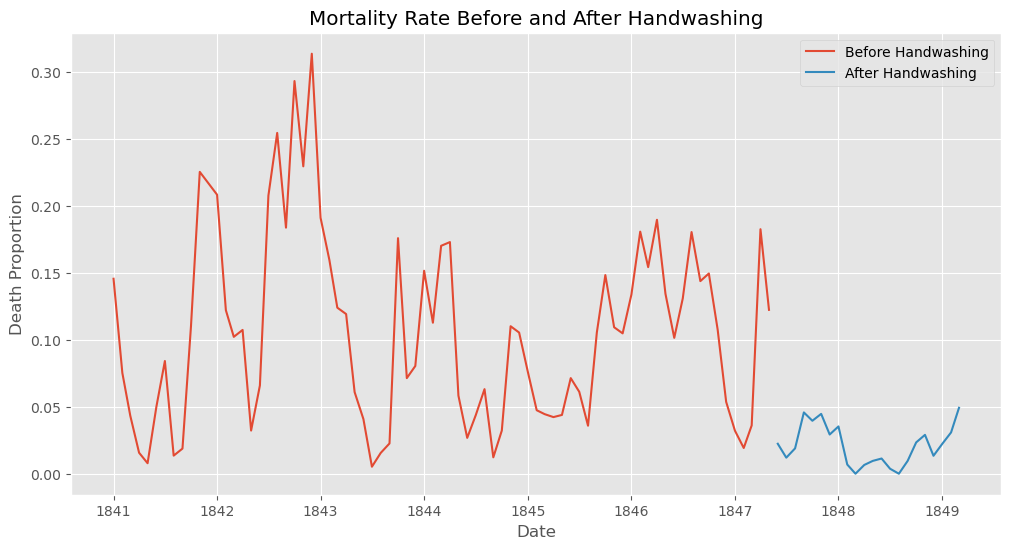

In [49]:
plt.figure(figsize=(12,6))

plt.plot(
    before_washing['date'],
    before_washing['proportion_deaths'],
    label='Before Handwashing'
)

plt.plot(
    after_washing['date'],
    after_washing['proportion_deaths'],
    label='After Handwashing'
)

plt.title(
    'Mortality Rate Before and After Handwashing'
)

plt.xlabel('Date')
plt.ylabel('Death Proportion')

plt.legend()

plt.show()

#### Average Mortality Before Handwashing

In [51]:
before_mean = (
    before_washing['proportion_deaths']
    .mean()
)

before_mean

np.float64(0.10504998260908789)

#### Average Mortality After Handwashing

In [52]:
after_mean = (
    after_washing['proportion_deaths']
    .mean()
)

after_mean

np.float64(0.021093375097254535)

#### Calculate Improvement

In [53]:
improvement = (
    before_mean -
    after_mean
)

improvement

np.float64(0.08395660751183336)

#### Percentage Reduction

In [54]:
reduction_percent = (
    improvement /
    before_mean
) * 100

print(
    f"Reduction in mortality: {reduction_percent:.2f}%"
)

Reduction in mortality: 79.92%


###  Additional Insights and Findings

#### Insight 1: Which Clinic Had Higher Average Mortality?

In [56]:
yearly.groupby('clinic')['proportion_deaths'].mean().sort_values(ascending=False)

clinic
clinic 1    0.098505
clinic 2    0.040400
Name: proportion_deaths, dtype: float64

###### Identify which clinic consistently had the highest maternal mortality.

#### Insight 2: Worst Year for Maternal Deaths

In [57]:
yearly.loc[
    yearly['proportion_deaths'].idxmax()
]

year                     1842
births                   3287
deaths                    518
clinic               clinic 1
proportion_deaths    0.157591
Name: 1, dtype: object

###### Find the most dangerous year for mothers.

#### Insight 3: Best Year for Maternal Survival

In [58]:
yearly.loc[
    yearly['proportion_deaths'].idxmin()
]

year                     1845
births                   3241
deaths                     66
clinic               clinic 2
proportion_deaths    0.020364
Name: 10, dtype: object

###### Identify the safest year in the dataset.

#### Insight 4: Total Lives Potentially Saved

In [59]:
before_mean = before_washing['proportion_deaths'].mean()
after_mean = after_washing['proportion_deaths'].mean()

monthly['expected_deaths_without_handwashing'] = (
    monthly['births'] * before_mean
)

monthly['saved_lives'] = (
    monthly['expected_deaths_without_handwashing']
    - monthly['deaths']
)

monthly['saved_lives'].sum()

np.float64(546.7378449493937)

###### Estimate how many lives may have been saved after handwashing.

#### Insight 5: Highest Mortality Month

In [60]:
monthly.loc[
    monthly['proportion_deaths'].idxmax()
]

date                                   1842-12-01 00:00:00
births                                                 239
deaths                                                  75
proportion_deaths                                 0.313808
expected_deaths_without_handwashing              25.106946
saved_lives                                     -49.893054
Name: 22, dtype: object

######  Determine the deadliest month.

#### Insight 6: Lowest Mortality Month

In [61]:
monthly.loc[
    monthly['proportion_deaths'].idxmin()
]

date                                   1848-03-01 00:00:00
births                                                 276
deaths                                                   0
proportion_deaths                                      0.0
expected_deaths_without_handwashing              28.993795
saved_lives                                      28.993795
Name: 85, dtype: object

###### Determine the safest month.

#### Insight 7: Monthly Mortality Trend

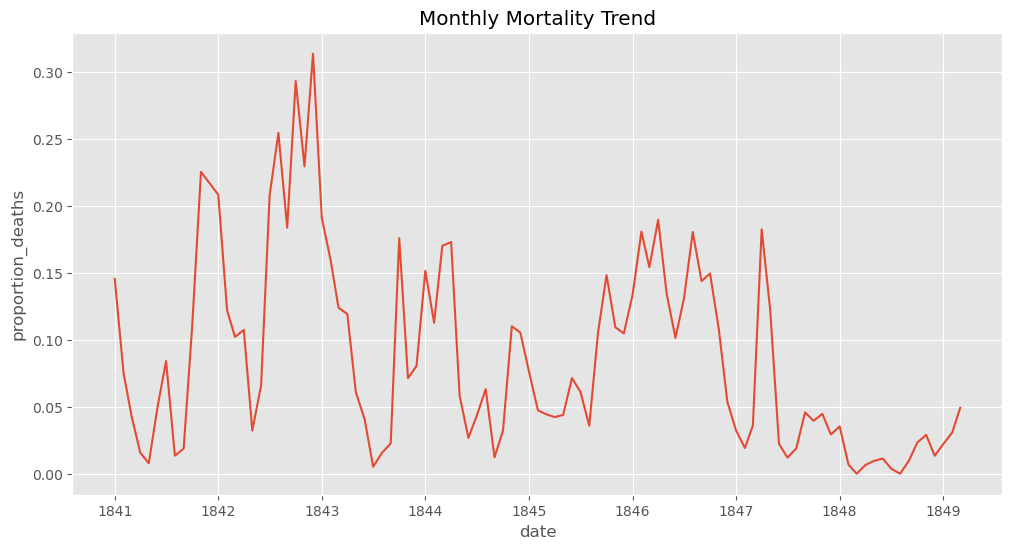

In [62]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=monthly,
    x='date',
    y='proportion_deaths'
)

plt.title('Monthly Mortality Trend')
plt.show()

###### Observe whether mortality decreases over time.

#### Insight 8: Distribution of Mortality Rates

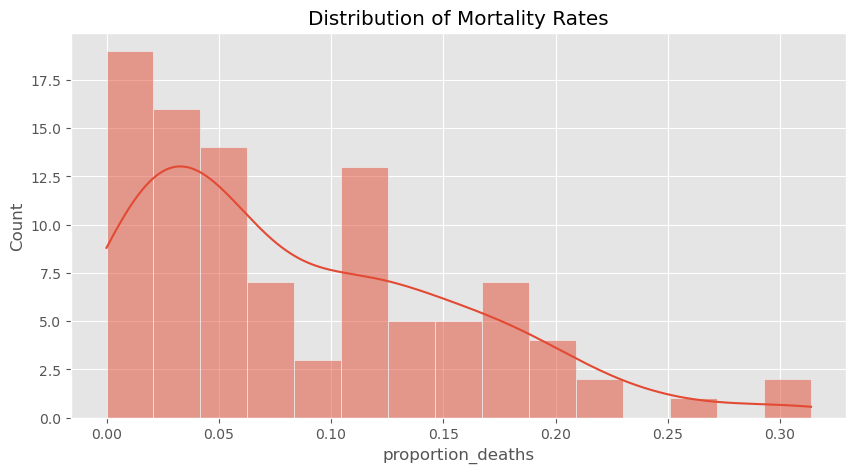

In [63]:
plt.figure(figsize=(10,5))

sns.histplot(
    monthly['proportion_deaths'],
    bins=15,
    kde=True
)

plt.title('Distribution of Mortality Rates')
plt.show()

###### Understand the spread of mortality rates.

#### Insight 9: Average Deaths Before vs After

In [64]:
print("Before:", before_washing['deaths'].mean())
print("After :", after_washing['deaths'].mean())

Before: 27.105263157894736
After : 6.454545454545454


###### Compare average monthly deaths directly.

#### Insight 10: Public Health Impact

In [65]:
reduction_percent

np.float64(79.92062961519258)

######  Quantify the reduction in mortality due to handwashing.